In [6]:
import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# 1. Definir los Gene Sets más relevantes para tu tesis (Placenta, Inmuno, Metabo)
# En 2026, MSigDB ya está en versiones superiores, usamos las constantes de categoría
gene_sets_list = [
    'MSigDB_Hallmark_2020',            # Los 50 procesos biológicos "maestros"
    'KEGG_2021_Human',                # Metabolismo clásico (sigue siendo estándar)
    'GO_Biological_Process_2023',      # Para ver procesos celulares específicos
    'Reactome_2022',                   # Vías de señalización detalladas
    'WikiPathways_2019_Human',         # Alternativa curada por la comunidad
    'Lipid_Metabolism_2024'            # Muy relevante para metabolismo placentario
]

# 2. Correr el análisis Preranked
# Usamos el archivo .rnk que generamos con limma en R
pre_res = gp.prerank(
    rnk="placenta_sex_ranking.rnk",
    gene_sets=gene_sets_list,
    threads=8,                         # Aprovechá los núcleos del cluster Cranex
    min_size=15,
    max_size=500,
    permutation_num=1000,              # Para publicación se recomienda 1000
    outdir='GSEA_Results_Placenta_2026',
    format='pdf',                      # PDF es mejor para las figuras de la tesis
    seed=42,
    verbose=True
)

# 3. Mostrar los 10 resultados más enriquecidos (Enriched)
print(pre_res.res2d.head(10))

2026-02-24 13:11:47,153 [WARNING] Duplicated values found in preranked stats: 1.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-24 13:11:47,154 [INFO] Parsing data files for GSEA.............................
2026-02-24 13:11:47,183 [INFO] Enrichr library gene sets already downloaded in: C:\Users\Fran\.cache/gseapy, use local file
2026-02-24 13:11:47,189 [INFO] Enrichr library gene sets already downloaded in: C:\Users\Fran\.cache/gseapy, use local file
2026-02-24 13:11:47,198 [INFO] Enrichr library gene sets already downloaded in: C:\Users\Fran\.cache/gseapy, use local file
2026-02-24 13:11:47,251 [INFO] Enrichr library gene sets already downloaded in: C:\Users\Fran\.cache/gseapy, use local file
2026-02-24 13:11:47,301 [INFO] Enrichr library gene sets already downloaded in: C:\Users\Fran\.cache/gseapy, use local file
2026-02-24 13:11:49,272 [ERROR] No supported gene_sets: Lipid_Metabolism_2024
2026-02-24 13:11:49,408 [INFO] 3520 gen

      Name                                               Term        ES  \
0  prerank  GO_Biological_Process_2023__Regulation Of Smoo... -0.631606   
1  prerank  GO_Biological_Process_2023__Response To dsRNA ... -0.558032   
2  prerank  Reactome_2022__Mitochondrial tRNA Aminoacylati...  -0.55437   
3  prerank  GO_Biological_Process_2023__B Cell Proliferati... -0.514699   
4  prerank  Reactome_2022__Cell Recruitment (Pro-Inflammat... -0.527887   
5  prerank  GO_Biological_Process_2023__Lymphocyte Activat... -0.524217   
6  prerank  GO_Biological_Process_2023__Positive Regulatio... -0.513707   
7  prerank  GO_Biological_Process_2023__Positive Regulatio... -0.555603   
8  prerank  GO_Biological_Process_2023__RNA-mediated Gene ... -0.507856   
9  prerank  GO_Biological_Process_2023__Respiratory Chain ... -0.533276   

        NES NOM p-val FDR q-val FWER p-val  Tag %  Gene %  \
0 -1.982942       0.0   0.20696       0.18  10/19  16.00%   
1 -1.822759   0.00203       1.0       0.84  15/24  2

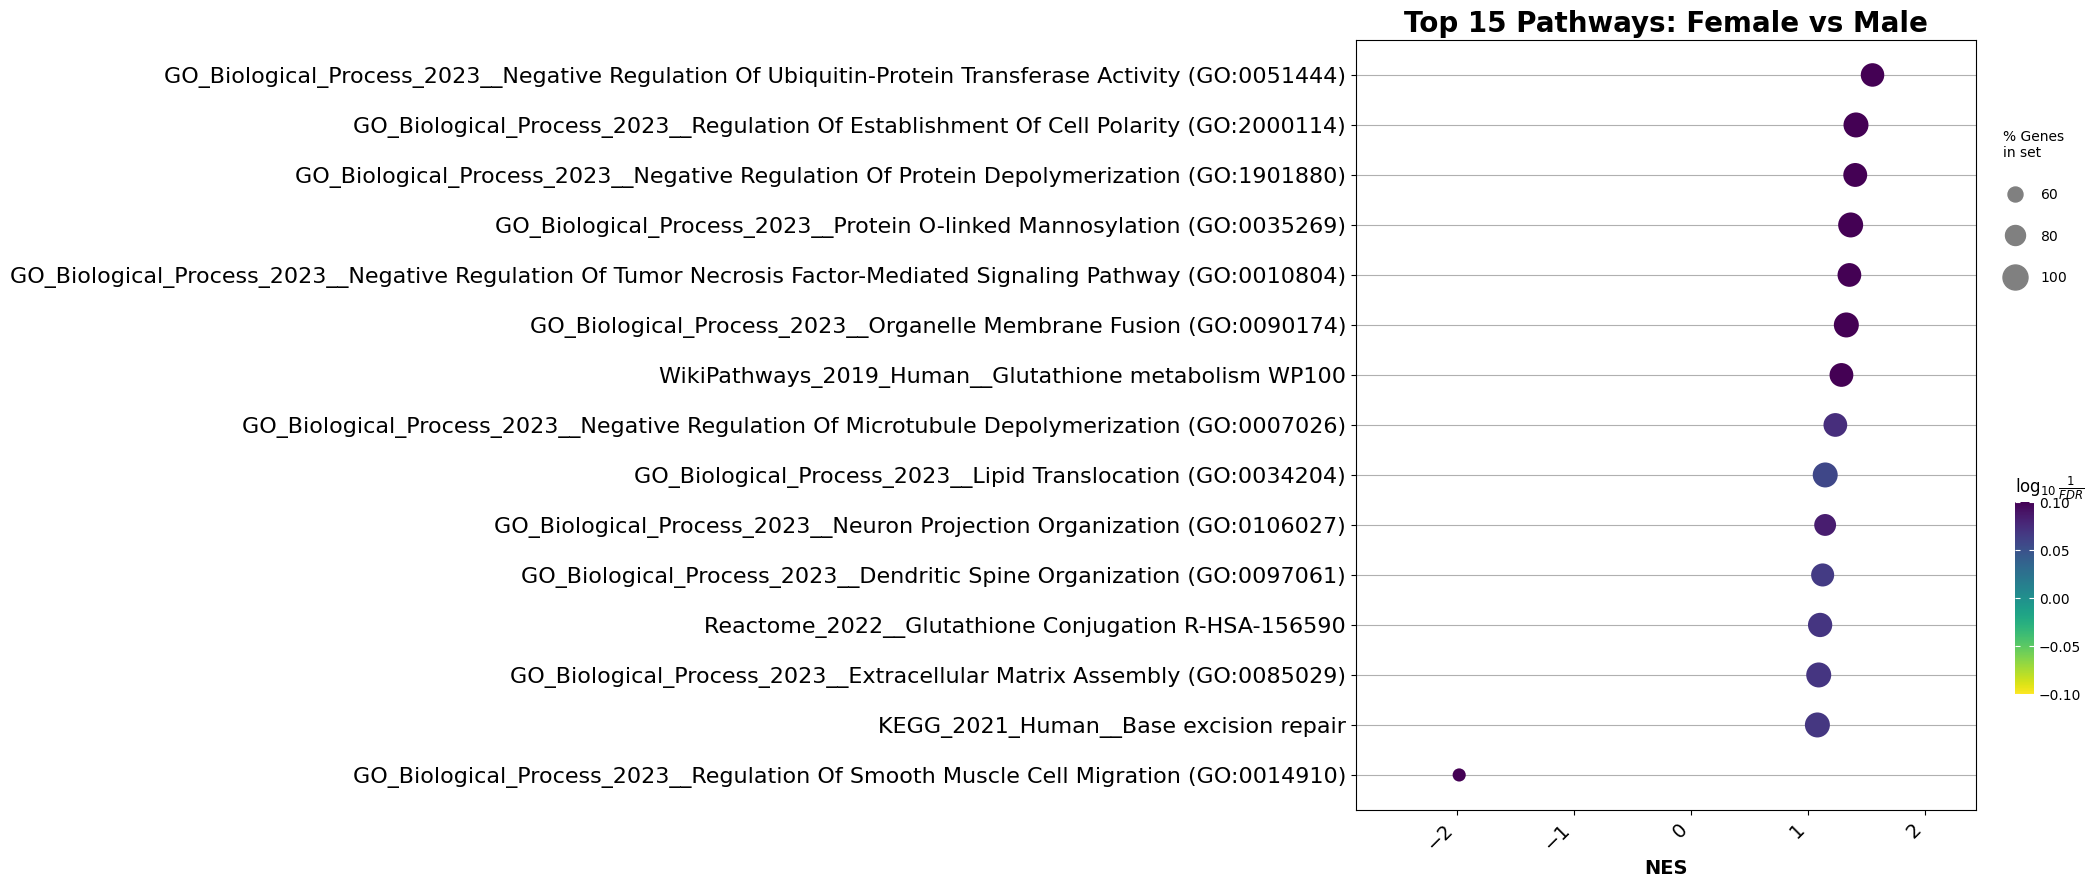

In [4]:
# 1. Extraer los resultados
results_df = pre_res.res2d

# Ajustamos el tamaño con dot_scale (probá con un valor entre 2 y 5)
ax = gp.dotplot(
    results_df,
    column="FDR q-val", 
    x='NES',           # Volvemos a NES para explicarte la dirección
    size=3,            # <--- Achicamos el tamaño base
    top_term=15,
    cutoff=1.0,
    figsize=(10, 10),
    title="Top 15 Pathways: Female vs Male",
    xticklabels_rot=45,
    show_ring=False    # Sacamos el anillo para que se vea más limpio si son chicos
)

plt.savefig("GSEA_Dotplot_Ajustado.pdf", bbox_inches='tight')
plt.show()

Top 15 Vías por significancia:
                                                 Term       NES FDR q-val
0   GO_Biological_Process_2023__Regulation Of Smoo... -1.982942   0.20696
1   GO_Biological_Process_2023__Response To dsRNA ... -1.822759       1.0
2   Reactome_2022__Mitochondrial tRNA Aminoacylati... -1.767543       1.0
3   GO_Biological_Process_2023__B Cell Proliferati... -1.748071       1.0
4   Reactome_2022__Cell Recruitment (Pro-Inflammat...  -1.74447       1.0
5   GO_Biological_Process_2023__Lymphocyte Activat... -1.704052       1.0
6   GO_Biological_Process_2023__Positive Regulatio...  -1.70328       1.0
7   GO_Biological_Process_2023__Positive Regulatio... -1.703034       1.0
8   GO_Biological_Process_2023__RNA-mediated Gene ... -1.699298       1.0
9   GO_Biological_Process_2023__Respiratory Chain ... -1.695814       1.0
10  GO_Biological_Process_2023__Regulation Of Kera... -1.689622   0.98908
11  GO_Biological_Process_2023__Organelle Fission ... -1.677714       1.0
12     

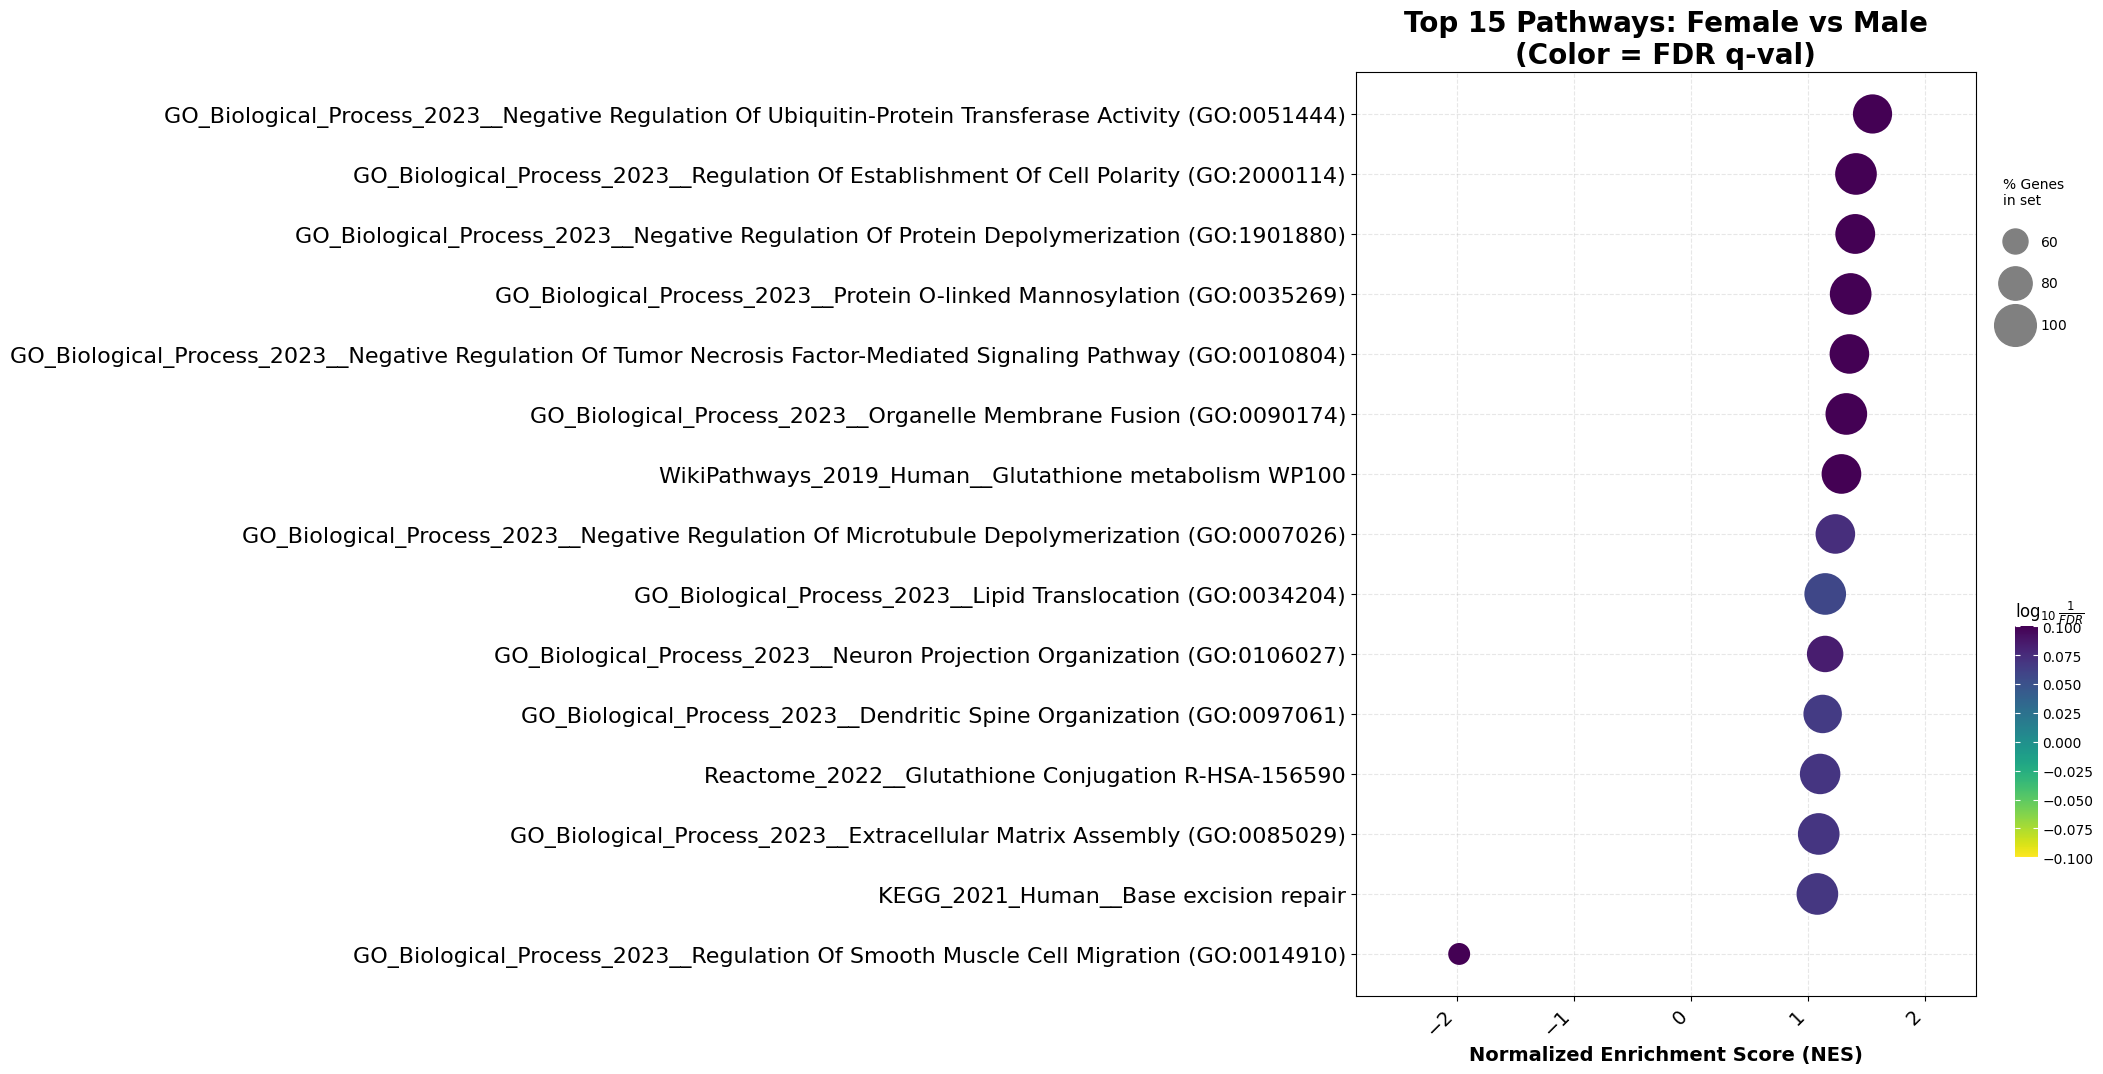

In [5]:
# 2. Mostrar la tabla en consola para ver los valores reales
print("Top 15 Vías por significancia:")
print(results_df[['Term', 'NES', 'FDR q-val']].head(15))

# 3. Crear el Dotplot ajustado
ax = gp.dotplot(
    results_df,
    column="FDR q-val",     # El color representa el p-valor ajustado
    x='NES',                # Posición en X según el Enriquecimiento
    dot_scale=4,            # <--- ACHICAMOS los círculos (probá 3, 4 o 5)
    top_term=15,
    cutoff=1.0,             # Mostramos todo aunque no sea < 0.05
    figsize=(10, 12),
    title="Top 15 Pathways: Female vs Male\n(Color = FDR q-val)",
    xticklabels_rot=45,
    cmap='viridis_r'        # Invertimos el color: más amarillo/brillante = más significativo
)

plt.xlabel("Normalized Enrichment Score (NES)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("GSEA_Dotplot_Final.pdf", bbox_inches='tight')
plt.show()

## Comparando menos vias 

2026-02-24 14:26:46,391 [WARNING] Duplicated values found in preranked stats: 1.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-24 14:26:46,395 [INFO] Parsing data files for GSEA.............................
2026-02-24 14:26:46,500 [INFO] Enrichr library gene sets already downloaded in: C:\Users\Fran\.cache/gseapy, use local file
2026-02-24 14:26:46,555 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-02-24 14:26:46,558 [INFO] 0050 gene_sets used for further statistical testing.....
2026-02-24 14:26:46,559 [INFO] Start to run GSEA...Might take a while..................
2026-02-24 14:26:54,606 [INFO] Congratulations. GSEApy runs successfully................



Top 10 Vías de Hallmark por FDR:
                             Term       NES FDR q-val
1           Inflammatory Response -1.376981  0.287115
3           Xenobiotic Metabolism -1.304646  0.335134
5         Cholesterol Homeostasis -1.269674  0.350307
4                  UV Response Up -1.274319  0.397959
2           Fatty Acid Metabolism -1.312325   0.40116
7      Wnt-beta Catenin Signaling  -1.23235  0.403536
6   TNF-alpha Signaling via NF-kB -1.235795  0.442749
0            Bile Acid Metabolism -1.392294  0.488195
8                      Myogenesis -1.190438  0.567449
10         Estrogen Response Late -1.165225  0.603241


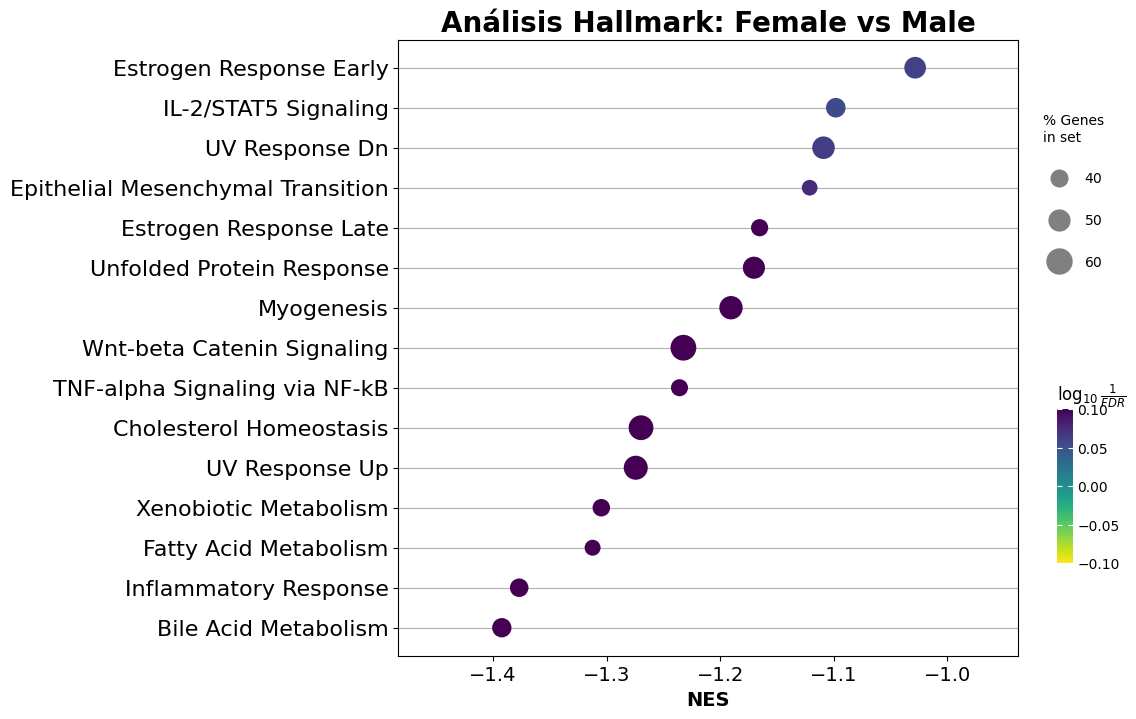

In [7]:
import gseapy as gp
import matplotlib.pyplot as plt

# 1. Correr el análisis usando el ranking que ya tenés
# Usamos solamente 'MSigDB_Hallmark_2020'
res_hallmark = gp.prerank(
    rnk="placenta_limpia_hallmark.rnk", # El archivo que generamos en R
    gene_sets='MSigDB_Hallmark_2020',    # LA CLAVE: solo 50 comparaciones
    threads=8,
    permutation_num=1000,
    outdir='GSEA_Hallmark_Only',
    seed=42,
    verbose=True
)

# 2. Extraer y mostrar los resultados
df_h = res_hallmark.res2d

# Ordenamos por FDR para ver si alguno bajó de 1.0
print("Top 10 Vías de Hallmark por FDR:")
print(df_h[['Term', 'NES', 'FDR q-val']].sort_values('FDR q-val').head(10))

# 3. Graficar Dotplot (achicando los círculos)
ax = gp.dotplot(
    df_h,
    column="FDR q-val", 
    x='NES',
    dot_scale=4, 
    top_term=15,
    cutoff=1.0, # Mostramos todo para ver qué tan cerca estamos del 0.05
    figsize=(10, 8),
    title="Análisis Hallmark: Female vs Male",
    cmap='viridis_r'
)

plt.savefig("GSEA_Hallmark_Final.pdf", bbox_inches='tight')
plt.show()

## Con tabla de ranking agresivo

2026-02-24 14:30:07,826 [WARNING] Duplicated values found in preranked stats: 1.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


--- RESULTADOS RANKING AGRESIVO ---
                            Term       NES FDR q-val
3          Xenobiotic Metabolism -1.296181  0.290075
2          Fatty Acid Metabolism -1.317856  0.297744
1          Inflammatory Response -1.343444  0.320083
6  TNF-alpha Signaling via NF-kB -1.227133  0.408678
0           Bile Acid Metabolism -1.367399  0.450117
5        Cholesterol Homeostasis -1.231298  0.452284
4                 UV Response Up -1.233359  0.531938
7     Wnt-beta Catenin Signaling -1.187476  0.571148
9                     Myogenesis -1.161141   0.61366
8         Estrogen Response Late -1.170246  0.615271


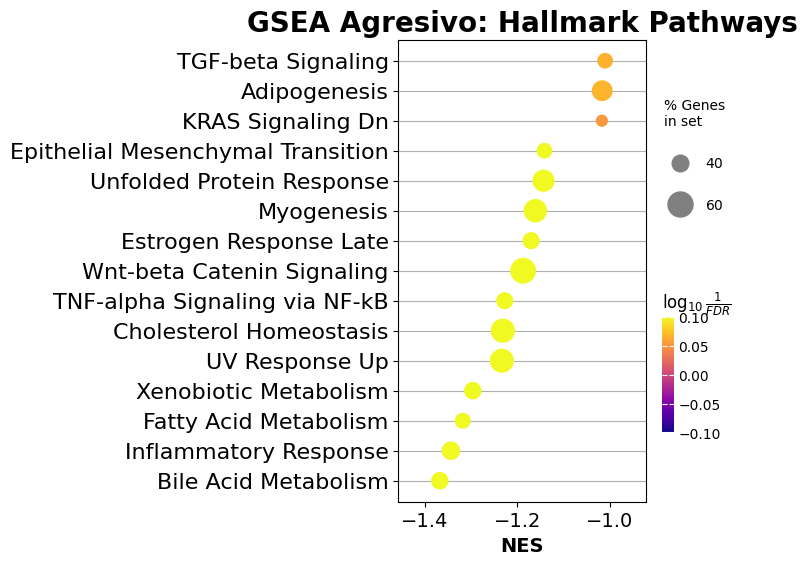

In [8]:
# Correr con el ranking agresivo y Hallmark
pre_res_final = gp.prerank(
    rnk="placenta_agresiva.rnk", 
    gene_sets='MSigDB_Hallmark_2020', 
    threads=8,
    permutation_num=1000,
    outdir='GSEA_Agresivo_Hallmark',
    seed=42
)

df_final = pre_res_final.res2d

# El momento de la verdad: ¿Bajó el FDR?
print("--- RESULTADOS RANKING AGRESIVO ---")
print(df_final[['Term', 'NES', 'FDR q-val']].sort_values('FDR q-val').head(10))

# Graficamos el Dotplot final
gp.dotplot(df_final, column="FDR q-val", x='NES', 
           dot_scale=5, top_term=15, cutoff=1.0, 
           title="GSEA Agresivo: Hallmark Pathways",
           cmap='plasma') # 'plasma' resalta mejor los valores bajos

plt.savefig("GSEA_Hallmark_Agresivo.pdf", bbox_inches='tight')
plt.show()